In [159]:
import sys
from pathlib import Path

current_folder = str(Path().resolve())
if current_folder in sys.path:
    sys.path.remove(current_folder)

sys.path.insert(0, current_folder)
import matplotlib.pyplot as plt
import numpy as np
from hw_pricer import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# Ez csak ahhoz kellett, hogy jó .py file töltődik-e be. Először az src mappában lévőt akarta beimportálni, és így a MarketModel class hibára futott, amikor használni szerettem volna.
import importlib
import hw_model

importlib.reload(hw_model)
print(hw_model.__file__)

/Users/tothpatrik/QuantCourseBP/homeworks/9180744/my_homeworks/Building_blocks_házi/hw_model.py


In [160]:
underlying = Stock.BLUECHIP_BANK
modell = MarketModel(underlying)
params = Params()

spot_price = modell.spot
strike_price = 100.0
expiry = 1.0
payout = 1.0
spot_range = np.linspace(10, 200, 500)
digital_call = EuropeanDigitalContract(underlying, PutCallFwd.CALL, LongShort.LONG, strike_price, expiry, payout)
digital_call_price = EuropeanDigitalAnalyticPricer(digital_call, modell, params)

epsilons = [150.0, 125.0, 100.0, 50.0, 10.0] # epszilon értékkel tolom el a strike price-t, effektíve parciális deriváljuk a call árát K szerint
digital_prices = []
spread_prices = {eps: [] for eps in epsilons}

for S in spot_range:
    modell.spot = S
    digital_prices.append(digital_call_price.calc_fair_value())
    for eps in epsilons:
        K1 = strike_price - (eps / 2.0) # alacsonyabb strike callt veszek
        K2 = strike_price + (eps / 2.0) # magasabb strike callt eladok, irányt a Contract class beépített direction tulajdonsága intézi
        long_call = EuropeanContract(underlying, PutCallFwd.CALL, LongShort.LONG, K1, expiry)
        long_call_price = EuropeanAnalyticPricer(long_call, modell, params)
        short_call = EuropeanContract(underlying, PutCallFwd.CALL, LongShort.SHORT, K2, expiry)
        short_call_price = EuropeanAnalyticPricer(short_call, modell, params)

        bull_spread_price = (long_call_price.calc_fair_value() + short_call_price.calc_fair_value()) / eps #
        spread_prices[eps].append(bull_spread_price)

modell.spot = spot_price

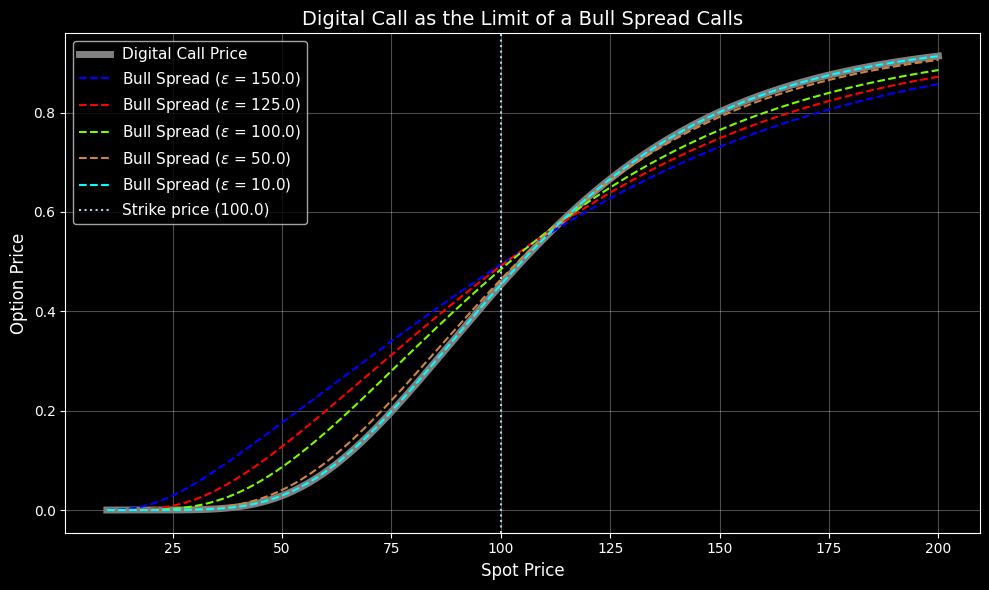

In [161]:
plt.figure(figsize=(10, 6))
plt.plot(spot_range, digital_prices, label='Digital Call Price', color='grey', linewidth=5)

colors = ['blue', 'red', 'lawngreen', 'peru', 'cyan']
for i, eps in enumerate(epsilons):
    plt.plot(spot_range, spread_prices[eps], label=f'Bull Spread ($\epsilon$ = {eps})', color=colors[i], linestyle='--')

plt.axvline(strike_price, color='lightblue', linestyle=':', label=f'Strike price ({strike_price})')
plt.title('Digital Call as the Limit of a Bull Spread Calls', fontsize=14)
plt.xlabel('Spot Price', fontsize=12)
plt.ylabel('Option Price', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ahogy epszilonnal tartok nullába a call opciókból álló bull spread ára (színes görbék) egyre közelítik a digitális call árát, vagyis limeszben a kettő meg fog egyezni.
(Azt nem tudom, miért nem pontosan a strike price-on keresztezik egymást a spread görbék, intuitívan azt gondolnám ott kellene.)